Funda Tan - COGS508 Experiment Analysis

This is a dual-language (Turkish and English) false memory experiment to explore DRM (Deese-Roediger-McDermott) Paradigm, which investigates how our brains sometimes create false memories. This experiment is about how our memory handles associations and how mental distractions—like solving math problems—affect our ability to distinguish between what we actually saw and what our brain thinks we saw.

In this experiment, I investigated the DRM (Deese-Roediger-McDermott) false memory effect across participants' native language and foreign language. I set up a 2x3 within-subjects experimental design with two independent variables: Language (Turkish and English) and Word Type. The Word Type variable has three levels: 'old' words that were actually studied, unrelated 'distractor' words, and semantically related 'critical lures'. Since every participant goes through all combinations of these conditions, both of the independent variables are within-subjects factors. To evaluate the effects of these manipulations, two dependent variables are measured: accuracy and reaction time.

1. Import required modules

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

2. Load and Combine Data

In [18]:
# Load participants data
all_files = glob.glob('data/*false_memory_experiment*.csv')
print(f"Participant count: {len(all_files)}")

dfs = []
for file in all_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Combine all individual dataframes into one
combined_df = pd.concat(dfs, ignore_index=True)

Participant count: 14


2. Create Tidy Dataset

In [19]:
# Filter for test words and get related columns
tidy_df = combined_df[combined_df['test_word'].notna()][
    ['participant', 'test_word', 'word_type', 'language', 'key_resp_test.corr', 'key_resp_test.rt']
].copy()

# Rename columns
tidy_df.rename(columns={
    'key_resp_test.corr': 'accuracy',
    'key_resp_test.rt': 'reaction_time'
}, inplace=True)

# Convert data to numeric and drop null responses
tidy_df['accuracy'] = pd.to_numeric(tidy_df['accuracy'])
tidy_df['reaction_time'] = pd.to_numeric(tidy_df['reaction_time'])

# Map language to Native vs Foreign explicitly
tidy_df['language'] = tidy_df['language'].map({
    'TR': 'Turkish (Native)', 
    'EN': 'English (Foreign)'
})

# Save the tidy dataset
tidy_df.to_csv('tidy_data.csv', index=False)

3. Visualization

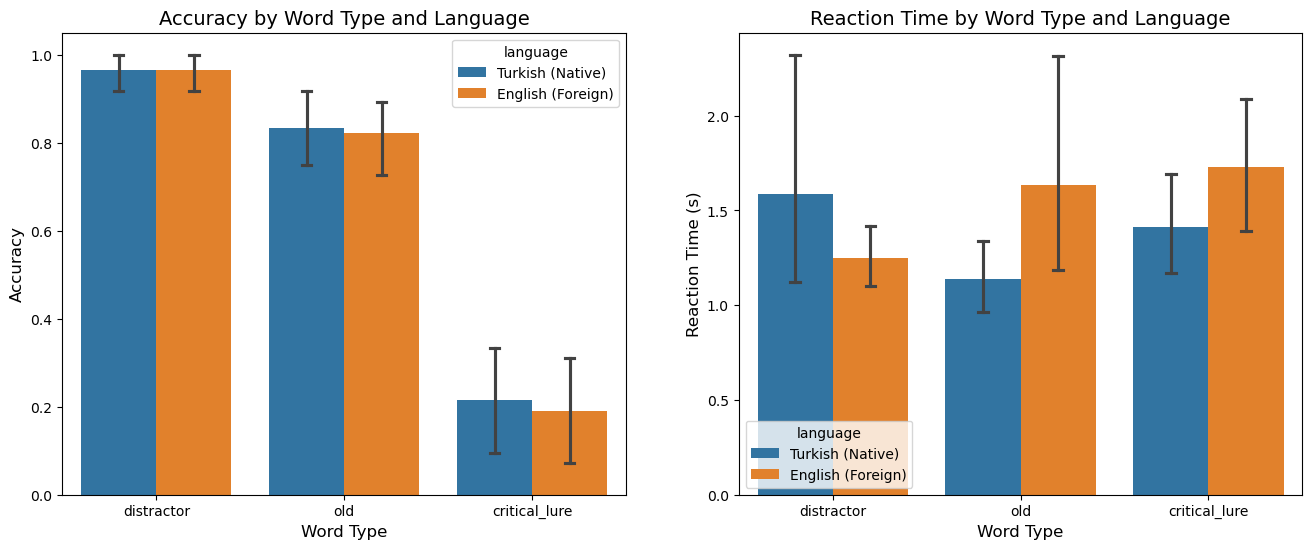

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy
sns.barplot(
    data=tidy_df, 
    x='word_type', 
    y='accuracy', 
    hue='language', 
    ax=axes[0], 
    capsize=.1, 
    errorbar='ci'
)
axes[0].set_title('Accuracy by Word Type and Language', fontsize=14)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Word Type', fontsize=12)

# Plot 2: Reaction Time
sns.barplot(
    data=tidy_df, 
    x='word_type', 
    y='reaction_time', 
    hue='language', 
    ax=axes[1], 
    capsize=.1, 
    errorbar='ci'
)
axes[1].set_title('Reaction Time by Word Type and Language', fontsize=14)
axes[1].set_ylabel('Reaction Time (s)', fontsize=12)
axes[1].set_xlabel('Word Type', fontsize=12)

plt.show()

4. Interpretation

Looking at the left plot which demonstrates accuracy (language as the categorical variable), participants are really good at recognizing the old words they actually studied and rejecting the completely new distractor words. However, their accuracy drops drastically for the critical_lure words. This means they are consistently falling for the semantic trap and falsely remembering those words.

Looking at the right plot which depicts the response time (language as the categorical variable), we observe a foreign language effect. Participants were noticeably slower to respond to even the actually studied ('old') words in English compared to their native Turkish, demonstrating the baseline cognitive load required to process information in a second language. However, 'critical lures' in English have the longest response time of all. This reveals a compound effect where the mental friction of resisting a semantic false memory is added directly on top of the already heavy cognitive load of foreign language processing.